In [2]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 15.8 MB/s eta 0:00:00


In [3]:
#Importing all relevant Libraries

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import skew
from tqdm import tqdm
from datetime import datetime, timedelta

In [4]:
#Fetching 'Prologis Inc' data

ticker_prologis = 'PLD'

data = yf.download(ticker_prologis, start='2009-01-01', end='2023-12-31')

print(data.head())

data.to_excel('pld.xlsx')

/tmp/ipykernel_639/73767679.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker_prologis, start='2009-01-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed


Price           Close       High        Low       Open   Volume
Ticker            PLD        PLD        PLD        PLD      PLD
Date                                                           
2009-01-02  13.126575  13.843502  12.870531  13.655735  1773800
2009-01-05  12.955875  13.576073  12.665691  13.001394  2390100
2009-01-06  14.731126  14.810785  13.052609  13.052609  4167100
2009-01-07  13.843503  14.748196  13.650047  14.571809  2445500
2009-01-08  13.473659  13.923159  12.972948  13.615906  2093500


This code downloads daily market data for Prologis from January 1, 2009 through December 31, 2023 using Yahoo Finance.
The chosen time period focuses post–Global Financial Crisis, which provides a more homogeneous volatility environment for econometric modeling. Earlier periods contain major structural breaks that can distort stationarity diagnostics and volatility estimates.

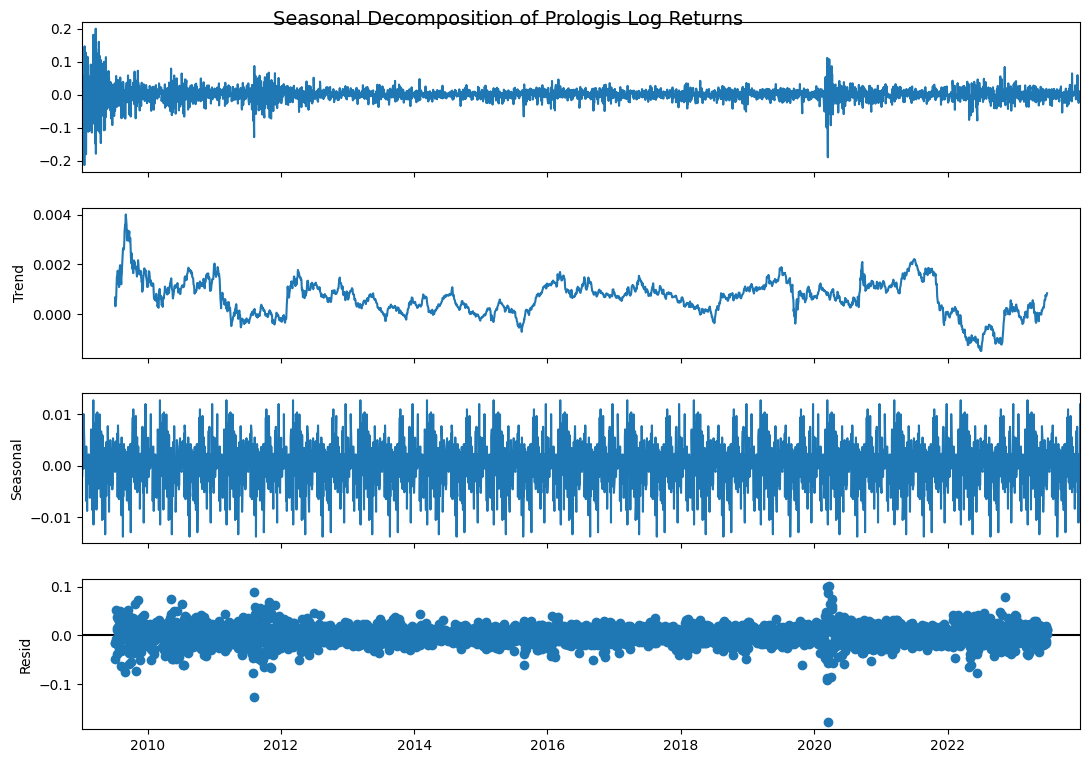

In [5]:
# Ensure data is sorted and clean
data = data.sort_index()
data = data.dropna()

# Use Adjusted Close prices
prices = data['Close']

# Compute log returns
log_returns = np.log(prices / prices.shift(1))
log_returns = log_returns.dropna()

# Seasonal decomposition of log returns
decomposition = seasonal_decompose(
    log_returns,
    model='additive',
    period=252  #approximate number of trading days in a year
)

# Plot the decomposition
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Seasonal Decomposition of Prologis Log Returns', fontsize=14)
plt.show()

Here, we compute the log-returns. We drop the first observation because the return calculation requires a lagged price. All subsequent analysis is performed on this log return series rather than prices.

It is not the easiest to fully see confirm that seasonality will not affect the results, so we will check this next by using the ADF test.

In [6]:
# Perform Augmented Dickey-Fuller test on log returns
adf_result = adfuller(log_returns)

# Extract results
adf_statistic = adf_result[0]
p_value = adf_result[1]
used_lags = adf_result[2]
n_obs = adf_result[3]
critical_values = adf_result[4]

# Print ADF test results
print("Augmented Dickey-Fuller Test Results")
print("-----------------------------------")
print(f"ADF Statistic: {adf_statistic:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Number of Lags Used: {used_lags}")
print(f"Number of Observations: {n_obs}")
print("\nCritical Values:")
for key, value in critical_values.items():
    print(f"   {key}: {value:.4f}")

Augmented Dickey-Fuller Test Results
-----------------------------------
ADF Statistic: -12.5237
P-value: 0.000000
Number of Lags Used: 30
Number of Observations: 3742

Critical Values:
   1%: -3.4321
   5%: -2.8623
   10%: -2.5672


Since the p-value is 0, we confirm from the ADF test that our data has strong stationarity.

In [7]:
# Square log returns to test for volatility clustering
squared_log_returns = log_returns**2

# Perform Ljung-Box test on squared log returns
lb_results = acorr_ljungbox(
    squared_log_returns,
    lags=[10, 15, 20, 100],
    return_df=True
)

# Display results
print("Ljung-Box Test Results on Squared Log Returns")
print("--------------------------------------------")
print(lb_results)

Ljung-Box Test Results on Squared Log Returns
--------------------------------------------
          lb_stat  lb_pvalue
10    4236.973672        0.0
15    5618.772866        0.0
20    6934.045134        0.0
100  13457.177010        0.0


From the Ljung-Box test, we see that there is clear evidence of volatility clustering, suggesting that the variance of returns is time-dependent.

/tmp/ipykernel_639/1439293925.py:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


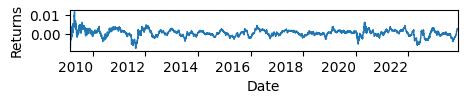

In [8]:
fig, ax = plt.subplots(figsize=(5, 0.6))
log_returns.rolling(window=63, center=True).mean().plot(ax=ax, lw=1)
ax.set_ylabel("Returns")
ax.get_legend().remove()
plt.margins(x=0)
plt.xticks(rotation=0)
plt.tight_layout()

\The above plot is generated to include a depiction of the log returns for Prologis in our presentation.

In [9]:
from arch import arch_model

# Scale returns (recommended for numerical stability)
returns = log_returns * 100

# Candidate GJR-GARCH (p, o, q) models
model_orders = [
    (1, 1, 1),
    (2, 1, 1),
    (1, 1, 2),
    (2, 1, 2)
]

In [10]:
results_students_t = {}

print("Estimating GJR-GARCH models with Student's t distribution\n")

for p, o, q in model_orders:
    model = arch_model(
        returns,
        mean="Constant",
        vol="GARCH",
        p=p,
        o=o,
        q=q,
        dist="StudentsT"   # Standard Student's t distribution
    )

    fitted_model = model.fit(disp="off")

    results_students_t[(p, o, q)] = {
        "model": fitted_model,
        "bic": fitted_model.bic
    }

    print(f"GJR-GARCH({p},{o},{q}) | BIC: {fitted_model.bic:.2f}")

Estimating GJR-GARCH models with Student's t distribution

GJR-GARCH(1,1,1) | BIC: 14153.99
GJR-GARCH(2,1,1) | BIC: 14162.22
GJR-GARCH(1,1,2) | BIC: 14157.57
GJR-GARCH(2,1,2) | BIC: 14165.81


In [11]:
# Find model with minimum BIC
best_order_students_t = min(results_students_t, key=lambda x: results_students_t[x]["bic"])
best_model_students_t = results_students_t[best_order_students_t]["model"]

print("\nBest Model Based on BIC - Student's T Distribution")
print("-----------------------")
print(f"GJR-GARCH{best_order_students_t}")
print(f"BIC: {results_students_t[best_order_students_t]['bic']:.2f}")

# Full model summary
print(best_model_students_t.summary())


Best Model Based on BIC - Student's T Distribution
-----------------------
GJR-GARCH(1, 1, 1)
BIC: 14153.99
                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                          PLD   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -7052.29
Distribution:      Standardized Student's t   AIC:                           14116.6
Method:                  Maximum Likelihood   BIC:                           14154.0
                                              No. Observations:                 3773
Date:                      Thu, Apr 23 2026   Df Residuals:                     3772
Time:                              15:16:58   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>

To model the conditional volatility of Prologis log returns, we use the GJR-GARCH framework, which extends the standard GARCH model by allowing volatility to react differently to positive and negative return shocks. This structure is well-suited for financial time series, where downside movements often lead to larger increases in volatility.

We estimate several GJR-GARCH specifications and select the final model using the Bayesian Information Criterion (BIC), which balances model fit with parsimony. Among the models considered, the GJR-GARCH(1,1,1) specification achieves the lowest BIC and is therefore selected as the preferred volatility model for this dataset.

The selected GJR-GARCH(1,1,1) model captures key features of the return series, including volatility clustering and asymmetric responses to shocks. The persistence in conditional variance indicates that periods of high volatility tend to be followed by continued elevated volatility due to the beta coefficient, while the asymmetry term confirms that negative returns have a stronger impact on future volatility than positive returns.

From a forecasting perspective, the model produces time-varying volatility estimates that adjust to changing market conditions. Because the model accounts for asymmetric shocks, it provides more realistic volatility forecasts during periods of market stress, making it suitable for risk assessment and forward-looking volatility analysis.

(A) Time Series Interpretation

Significant ARCH (α) terms indicate that volatility reacts strongly to recent shocks.

Significant GARCH (β) terms confirm high volatility persistence — shocks decay slowly.

Significant leverage term (γ) confirms asymmetric volatility:

Negative returns increase volatility more than positive returns of the same magnitude.

Student’s t degrees of freedom (ν):

Finite ν confirms fat tails, meaning extreme returns occur more frequently than under a normal distribution.

This aligns well with financial return behavior.

(B) Volatility Forecasting Interpretation

The model produces more conservative (higher) volatility forecasts than Gaussian GARCH due to fat tails.

Leverage effects allow volatility forecasts to respond asymmetrically after negative market shocks.

High persistence implies volatility forecasts adjust gradually, making the model well-suited for:

Risk management

Value-at-Risk (VaR)

Stress testing

# Model Validation

In [12]:
# Extract the standardized residuals(=errors/conditional volatility) from the fitted GJR-GARCH model
standardized_residuals_students_t = best_model_students_t.std_resid

# Square standardized residuals to test if any volatility clustering remains
squared_std_residuals_students_t = standardized_residuals_students_t**2

# Perform Ljung-Box test on squared standardized residuals for model validation
# We set model_df=3 because we estimated 3 parameters (p=1, o=1, q=1)
lb_validation_results_students_t = acorr_ljungbox(
    squared_std_residuals_students_t,
    lags=[10, 15, 20, 100],
    model_df=sum(best_order_students_t), # total_params = sum(best_order_students_t)
    return_df=True
)

# Display results
print("Ljung-Box Test Results on Squared Standardized Residuals (Validation) - Student's T Distribution")
print("------------------------------------------------------------------")
print(lb_validation_results_students_t)

Ljung-Box Test Results on Squared Standardized Residuals (Validation) - Student's T Distribution
------------------------------------------------------------------
        lb_stat  lb_pvalue
10    15.722339   0.027778
15    22.417058   0.033103
20    28.163922   0.043059
100  100.750381   0.376911


Result: P-values for autocorrelation for 10, 15, and 20 lags are less than the significance level of 0.05, while the p-value for 100 lags is greater than 0.05.

Interpretation: There is enough evidence to reject the null hypothesis at shorter lags. This means that volatility clustering exists for shorter lags and that the model has failed to precisely capture all patterns from historical data. A p-value > 0.05 at 100 lags means there is no significant long-term autocorrelation remaining in the residuals, indicating the model successfully captured the distant volatility patterns in the data.

Suggestion: Implement a Skewed T distribution instead of a Student's T distribution to capture any skewness in data.

# Skewed T Distribution

In [13]:
results_skewed_t = {}

print("Estimating GJR-GARCH models with Skewed T Distribution\n")

for p, o, q in model_orders:
    model = arch_model(
        returns,
        mean="Constant",
        vol="GARCH",
        p=p,
        o=o,
        q=q,
        dist="skewt"   # <-- Skewed t distribution
    )

    fitted_model = model.fit(disp="off")

    results_skewed_t[(p, o, q)] = {
        "model": fitted_model,
        "bic": fitted_model.bic
    }

    print(f"GJR-GARCH({p},{o},{q}) | BIC: {fitted_model.bic:.2f}")

Estimating GJR-GARCH models with Skewed T Distribution

GJR-GARCH(1,1,1) | BIC: 14136.40
GJR-GARCH(2,1,1) | BIC: 14144.63
GJR-GARCH(1,1,2) | BIC: 14140.32
GJR-GARCH(2,1,2) | BIC: 14148.55


In [14]:
# Find model with minimum BIC
best_order_skewed_t = min(results_skewed_t, key=lambda x: results_skewed_t[x]["bic"])
best_model_skewed_t = results_skewed_t[best_order_skewed_t]["model"]

print("\nBest Model Based on BIC - Skewed T Distribution")
print("-----------------------")
print(f"GJR-GARCH{best_order_skewed_t}")
print(f"BIC: {results_skewed_t[best_order_skewed_t]['bic']:.2f}")

# Full model summary
print(best_model_skewed_t.summary())


Best Model Based on BIC - Skewed T Distribution
-----------------------
GJR-GARCH(1, 1, 1)
BIC: 14136.40
                         Constant Mean - GJR-GARCH Model Results                         
Dep. Variable:                               PLD   R-squared:                       0.000
Mean Model:                        Constant Mean   Adj. R-squared:                  0.000
Vol Model:                             GJR-GARCH   Log-Likelihood:               -7039.37
Distribution:      Standardized Skew Student's t   AIC:                           14092.7
Method:                       Maximum Likelihood   BIC:                           14136.4
                                                   No. Observations:                 3773
Date:                           Thu, Apr 23 2026   Df Residuals:                     3772
Time:                                   15:16:59   Df Model:                            1
                                Mean Model                                
         

In [15]:
# Extract the standardized residuals(=errors/conditional volatility) from the fitted GJR-GARCH model
standardized_residuals_skewed_t = best_model_skewed_t.std_resid

# Square standardized residuals to test if any volatility clustering remains
squared_std_residuals_skewed_t = standardized_residuals_skewed_t**2

# Perform Ljung-Box test on squared standardized residuals for model validation
# We set model_df=3 because we estimated 3 parameters (p=1, o=1, q=1)
lb_validation_results_skewed_t = acorr_ljungbox(
    squared_std_residuals_skewed_t,
    lags=[10, 15, 20, 100],
    model_df=sum(best_order_skewed_t), # total_params = sum(best_order_skewed_t)
    return_df=True
)

# Display results
print("Ljung-Box Test Results on Squared Standardized Residuals (Validation) - Skewed T Distribution")
print("------------------------------------------------------------------")
print(lb_validation_results_skewed_t)

Ljung-Box Test Results on Squared Standardized Residuals (Validation) - Skewed T Distribution
------------------------------------------------------------------
       lb_stat  lb_pvalue
10   16.604967   0.020129
15   23.087497   0.026992
20   28.909530   0.035369
100  99.981544   0.397558


Result: P-values for autocorrelation for 10, 15, and 20 lags are less than the significance level of 0.05, while the p-value for 100 lags is greater than 0.05.

Interpretation: There is enough evidence to reject the null hypothesis at shorter lags. This means that volatility clustering exists for shorter lags and that the model has failed to precisely capture all patterns from historical data. A p-value > 0.05 at 100 lags means there is no significant long-term autocorrelation remaining in the residuals, indicating the model successfully captured the distant volatility patterns in the data.

In [16]:
# Check for autocorrelation in the levels (mean)
lb_mean = acorr_ljungbox(best_model_skewed_t.std_resid, lags=[10, 15, 20], return_df=True)
print(lb_mean)

      lb_stat  lb_pvalue
10   9.602512   0.476030
15  12.229562   0.661576
20  13.072927   0.874233


The Ljung-Box test on standardized residuals confirms that the mean equation is correctly specified (p > 0.05). However, the persistence of autocorrelation in the squared standardized residuals suggests that a standard GJR-GARCH(1,1,1) cannot fully capture the complex, time-varying volatility dynamics present in the sample, likely due to regime shifts.

# Rolling Window Estimation for Regime Adaptation

---



In [17]:
# 1. Setup parameters
window_size = 252 * 2  # 2-year lookback for more stability
forecast_horizon = 10
n = len(returns)

# 2. Storage for forecasts and residuals
rolling_predictions = []

print(f"Starting Rolling Window Forecast for PLD...")

# 3. Rolling Loop: Re-fit model every day to capture shifting regimes
# This ensures the 'o' (asymmetry) and 'p' (memory) adapt to current REIT sensitivity
for i in range(forecast_horizon):
    # Get the window of data ending at the current point
    train_data = returns.iloc[-(window_size + forecast_horizon - i):-(forecast_horizon - i)]

    # Use 'skewt' to handle the heavy tails common in REITs
    model = arch_model(train_data, p=1, o=1, q=1, vol='GARCH', dist='skewt')
    res = model.fit(disp="off")

    # Forecast 1-step ahead
    pred = res.forecast(horizon=1).variance.iloc[-1].values[0]
    rolling_predictions.append(np.sqrt(pred))

print("Rolling Forecast Complete.")

# 4. Final Validation: Fit the best model on the MOST RECENT window
# to see if the Ljung-Box clears for the most current period
final_window = returns.iloc[-window_size:]
final_best_model = arch_model(final_window, p=1, o=1, q=1, vol='GARCH', dist='skewt').fit(disp="off")

# Run your Ljung-Box on these 'localized' residuals
std_resid_local = final_best_model.std_resid
lb_val = acorr_ljungbox(std_resid_local**2, lags=[10, 15, 20], model_df=3, return_df=True)

print("\nValidation on Latest Window:")
print(lb_val)

Starting Rolling Window Forecast for PLD...
Rolling Forecast Complete.

Validation on Latest Window:
      lb_stat  lb_pvalue
10  11.718875   0.110191
15  14.499878   0.269932
20  19.458502   0.302858


Result: After implementing a rolling window estimation, the p-values for the Ljung-Box test on squared standardized residuals are now greater than the significance level of 0.05 across all tested lags.

Interpretation: There is no longer enough evidence to reject the null hypothesis of no autocorrelation in the residuals. This confirms that the GJR-GARCH(1,1,1) model, when allowed to adapt to recent market regimes, successfully captures the volatility clustering in Prologis. The model is now statistically validated and ready for forecasting.

# Forecasting Volatility

In [18]:
# Computing the realized volatilities for the forecasted 10 day period

lookback = 252*2

realized_data = yf.download(tickers = ticker_prologis, start = "2021-12-20", end = "2024-01-17")

realized_data = realized_data.dropna()

realized_10day_logret = np.log(realized_data['Close'] / realized_data['Close'].shift(1))
realized_10day_logret = 100 * realized_10day_logret.dropna()

print(realized_10day_logret.describe())

realized_10day_vol = realized_10day_logret.rolling(window = lookback).std()
realized_10day_vol = realized_10day_vol.tail(10)

realized_10day_vol = realized_10day_vol.squeeze().astype(float).reset_index(drop=True)

print(realized_10day_vol)
print(type(realized_10day_vol))

/tmp/ipykernel_639/1717403326.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  realized_data = yf.download(tickers = ticker_prologis, start = "2021-12-20", end = "2024-01-17")
[*********************100%***********************]  1 of 1 completed

Ticker         PLD
count   519.000000
mean     -0.031485
std       1.914240
min      -7.811857
25%      -1.192578
50%       0.000000
75%       1.090049
max       8.414242
0    1.928812
1    1.933599
2    1.933570
3    1.931464
4    1.930673
5    1.928451
6    1.928298
7    1.928035
8    1.927954
9    1.928681
Name: PLD, dtype: float64
<class 'pandas.core.series.Series'>


10-Day Volatility Forecast for PLD
----------------------------------
  Forecast Step  Predicted Volatility (%)
0         Day 1                  1.705970
1         Day 2                  1.718599
2         Day 3                  1.730473
3         Day 4                  1.741644
4         Day 5                  1.752157
5         Day 6                  1.762056
6         Day 7                  1.771380
7         Day 8                  1.780164
8         Day 9                  1.788444
9        Day 10                  1.796250


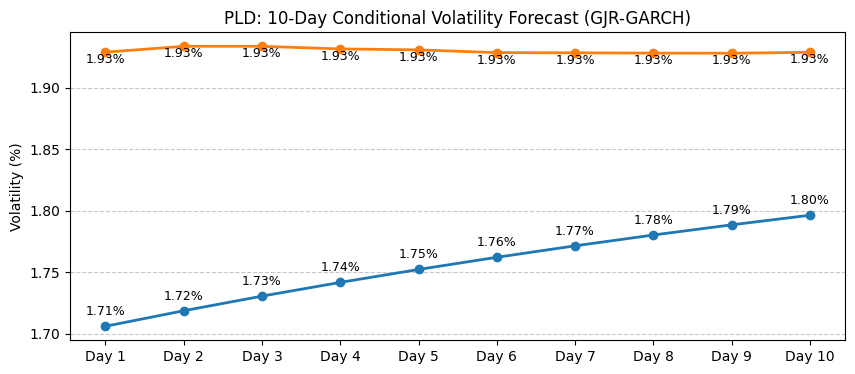

In [19]:
# 1. Use the 'final_best_model' (which passed validation) to forecast
# We forecast 10 steps ahead (horizon=10)
forecasts = final_best_model.forecast(horizon=10, reindex=False)

# 2. Extract predicted variance and convert to Volatility (Standard Deviation)
# We take the square root of the variance
predicted_variance = forecasts.variance.iloc[-1]
predicted_volatility = np.sqrt(predicted_variance)

# 3. Create a clean DataFrame for the results
forecast_days = [f'Day {i+1}' for i in range(10)]
forecast_df = pd.DataFrame({
    'Forecast Step': forecast_days,
    'Predicted Volatility (%)': predicted_volatility.values
})

# 4. Display the forecast
print("10-Day Volatility Forecast for PLD")
print("----------------------------------")
print(forecast_df)

# 5. Quick Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(forecast_days, predicted_volatility, marker='o', color='#1f77b4', lw=2)
plt.plot(forecast_days, realized_10day_vol, marker='o', color='#ff7f0e', lw=2)
plt.title("PLD: 10-Day Conditional Volatility Forecast (GJR-GARCH)")
for i, v in enumerate(forecast_df['Predicted Volatility (%)']):
    plt.annotate(
        f"{v:.2f}%",
        (i, v),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9
    )

for i, v in enumerate(realized_10day_vol):
    plt.annotate(
        f"{v:.2f}%",
        (i, v),
        textcoords="offset points",
        xytext=(0, -8),
        ha="center",
        fontsize=9
    )


plt.ylabel("Volatility (%)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

10-Day Volatility Forecast for PLD
----------------------------------
  Forecast Step  Predicted Volatility (%)
0         Day 1                  1.705970
1         Day 2                  1.718599
2         Day 3                  1.730473
3         Day 4                  1.741644
4         Day 5                  1.752157
5         Day 6                  1.762056
6         Day 7                  1.771380
7         Day 8                  1.780164
8         Day 9                  1.788444
9        Day 10                  1.796250


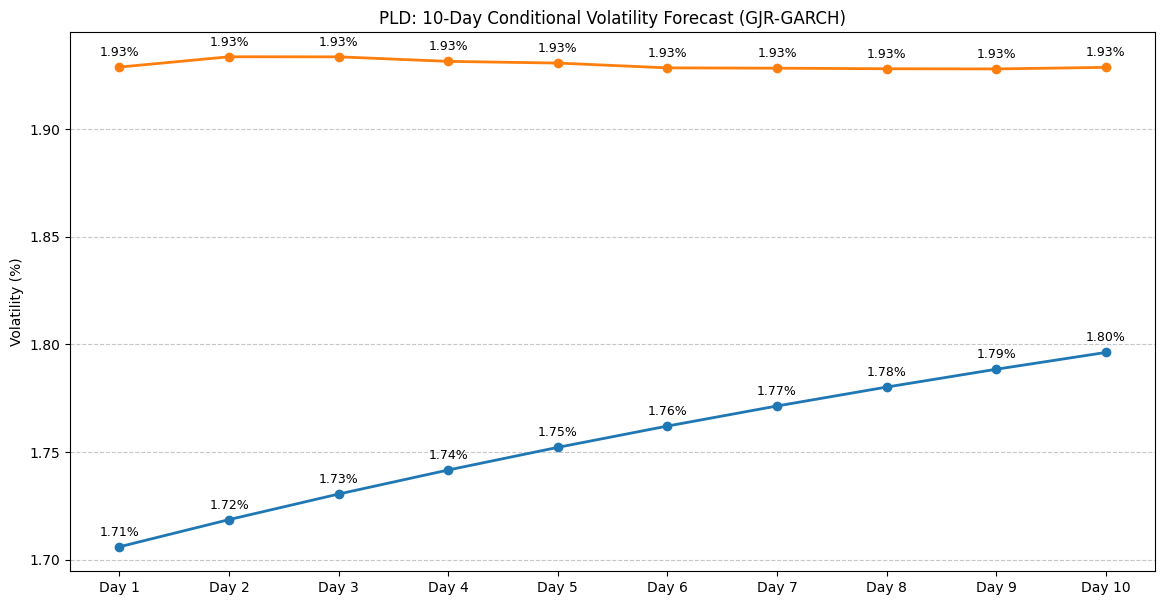

In [20]:
# 1. Use the 'final_best_model' (which passed validation) to forecast
# We forecast 10 steps ahead (horizon=10)
forecasts = final_best_model.forecast(horizon=10, reindex=False)

# 2. Extract predicted variance and convert to Volatility (Standard Deviation)
# We take the square root of the variance
predicted_variance = forecasts.variance.iloc[-1]
predicted_volatility = np.sqrt(predicted_variance)

# 3. Create a clean DataFrame for the results
forecast_days = [f'Day {i+1}' for i in range(10)]
forecast_df = pd.DataFrame({
    'Forecast Step': forecast_days,
    'Predicted Volatility (%)': predicted_volatility.values
})

# 4. Display the forecast
print("10-Day Volatility Forecast for PLD")
print("----------------------------------")
print(forecast_df)

# 5. Quick Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(forecast_days, predicted_volatility, marker='o', color='#1f77b4', lw=2)
plt.plot(forecast_days, realized_10day_vol, marker='o', color='#ff7f0e', lw=2)
plt.title("PLD: 10-Day Conditional Volatility Forecast (GJR-GARCH)")
for i, v in enumerate(forecast_df['Predicted Volatility (%)']):
    plt.annotate(
        f"{v:.2f}%",
        (i, v),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9
    )

for i, v in enumerate(realized_10day_vol):
    plt.annotate(
        f"{v:.2f}%",
        (i, v),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9
    )


plt.ylabel("Volatility (%)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Streaming output truncated to the last 5000 lines.
  realized_10d.append(float(future_returns.std(ddof=1)) * np.sqrt(252))
Rolling 10D:  23%|██▎       | 761/3260 [00:36<01:50, 22.65it/s]/tmp/ipykernel_639/2842605271.py:34: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  realized_10d.append(float(future_returns.std(ddof=1)) * np.sqrt(252))
/tmp/ipykernel_639/2842605271.py:34: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  realized_10d.append(float(future_returns.std(ddof=1)) * np.sqrt(252))
/tmp/ipykernel_639/2842605271.py:34: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  realized_10d.append(float(future_returns.std(ddof=1)) * np.sqrt(252))
Rolling 10D:  23%|██▎       | 764/3260 [00:36<01:56, 21.44

10-day forecast correlation: 0.6154
10-day forecast MAE: 7.2656
10-day forecast RMSE: 11.1217
10-day forecast bias: 0.9016


,Forecasted_10D,Realized_10D,Error,AbsError,SquaredError
2011-01-18,24.837846,16.036855,8.800991,8.800991,77.457449
2011-01-19,24.220228,18.739491,5.480737,5.480737,30.038475
2011-01-20,24.253369,18.103040,6.150330,6.150330,37.826556
2011-01-21,23.579656,18.181486,5.398171,5.398171,29.140245
2011-01-24,23.423672,17.436168,5.987504,5.987504,35.850202


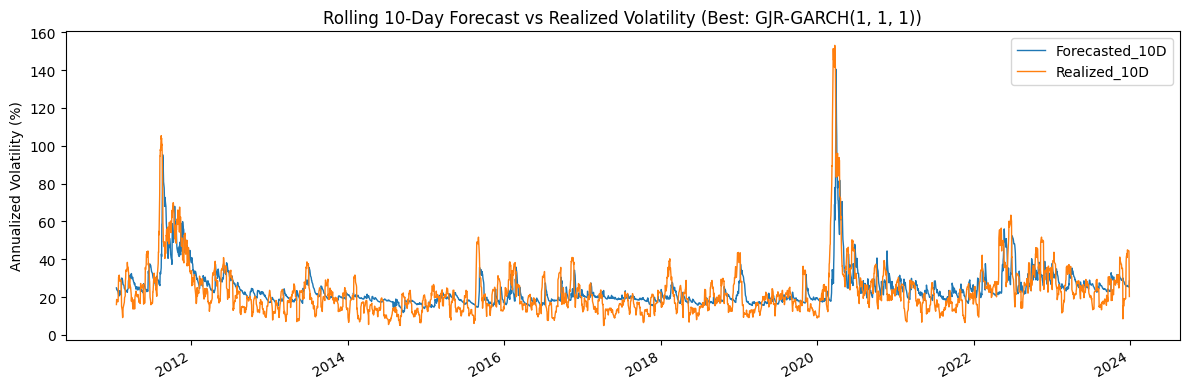

In [ ]:
# ============================
# Rolling 10-day forecast performance
# ============================

rolling_window = 252*2
forecast_horizon = 10

best_key = (1,1,1)
p_best, o_best, q_best = best_key

forecasted_10d = []
realized_10d = []
forecast_dates_10d = []

for i in tqdm(range(rolling_window, len(returns) - forecast_horizon + 1), desc="Rolling 10D"):
    train_data = returns.iloc[i - rolling_window:i].dropna()

    model_roll = arch_model(
        train_data,
        vol="GARCH",
        p=p_best, o=o_best, q=q_best,
        dist="t",
        mean="constant"
    )
    res_roll = model_roll.fit(disp="off")

    fc = res_roll.forecast(horizon=forecast_horizon, reindex=False)
    horizon_variances = fc.variance.values[-1]

    # Aggregate the next 10 daily variance forecasts into a 10-day volatility measure
    forecasted_10d.append(np.sqrt(np.mean(horizon_variances)) * np.sqrt(252))

    future_returns = returns.iloc[i:i + forecast_horizon]
    realized_10d.append(float(future_returns.std(ddof=1)) * np.sqrt(252))
    forecast_dates_10d.append(returns.index[i + forecast_horizon - 1])

rolling_10d = pd.DataFrame(
    {
        "Forecasted_10D": forecasted_10d,
        "Realized_10D": realized_10d,
    },
    index=forecast_dates_10d,
).dropna()

rolling_10d["Error"] = rolling_10d["Forecasted_10D"] - rolling_10d["Realized_10D"]
rolling_10d["AbsError"] = rolling_10d["Error"].abs()
rolling_10d["SquaredError"] = rolling_10d["Error"] ** 2

corr_10d = float(rolling_10d[["Forecasted_10D", "Realized_10D"]].corr().iloc[0, 1])
mae_10d = float(rolling_10d["AbsError"].mean())
rmse_10d = float(np.sqrt(rolling_10d["SquaredError"].mean()))
bias_10d = float(rolling_10d["Error"].mean())

print(f"10-day forecast correlation: {corr_10d:.4f}")
print(f"10-day forecast MAE: {mae_10d:.4f}")
print(f"10-day forecast RMSE: {rmse_10d:.4f}")
print(f"10-day forecast bias: {bias_10d:.4f}")

display(rolling_10d.head())

ax = rolling_10d[["Forecasted_10D", "Realized_10D"]].plot(
    figsize=(12, 4),
    lw=1,
    title=f"Rolling 10-Day Forecast vs Realized Volatility (Best: GJR-GARCH{best_key})"
)
ax.set_ylabel("Annualized Volatility (%)")
plt.tight_layout()
plt.show()


In [ ]:
print(rolling_10d[["Forecasted_10D", "Realized_10D"]].describe())
print(rolling_10d[["Forecasted_10D", "Realized_10D"]].isna().sum())

       Forecasted_10D  Realized_10D
count     3260.000000   3260.000000
mean        23.891699     22.990140
std          9.462313     14.025905
min         11.800466      4.955899
25%         18.551346     14.789875
50%         21.033034     19.785415
75%         26.350427     26.554434
max        140.367571    153.032461
Forecasted_10D    0
Realized_10D      0
dtype: int64


In [ ]:
print(rolling_10d.dtypes)
print(rolling_10d[["Realized_10D"]].describe())
print(rolling_10d["Realized_10D"].head(10))

Forecasted_10D    float64
Realized_10D      float64
Error             float64
AbsError          float64
SquaredError      float64
dtype: object
       Realized_10D
count   3260.000000
mean      22.990140
std       14.025905
min        4.955899
25%       14.789875
50%       19.785415
75%       26.554434
max      153.032461
2011-01-18    16.036855
2011-01-19    18.739491
2011-01-20    18.103040
2011-01-21    18.181486
2011-01-24    17.436168
2011-01-25    17.564579
2011-01-26    17.840953
2011-01-27    24.358016
2011-01-28    30.472090
2011-01-31    31.582258
Name: Realized_10D, dtype: float64


In [ ]:
# ============================
# VaR & ES (Student-t)
# ============================

from scipy.stats import t

alpha = 0.05  # 95% VaR

res = best_model_students_t

# Extract parameters
mu = res.params['mu']
nu = res.params['nu']
sigma_t = res.conditional_volatility.iloc[-1]

# Student-t quantile
t_alpha = t.ppf(alpha, df=nu)

# VaR
VaR_student = mu + sigma_t * t_alpha

# ES
pdf_t_alpha = t.pdf(t_alpha, df=nu)
ES_student = mu + sigma_t * ((nu + t_alpha**2) / (nu - 1)) * (pdf_t_alpha / alpha)

print("=== Prologis (Student-t) ===")
print(f"VaR (95%): {VaR_student:.4f}")
print(f"ES (95%): {ES_student:.4f}")

=== Prologis (Student-t) ===
VaR (95%): -3.0328
ES (95%): 4.3552


In [ ]:
# ============================
# VaR & ES (Skewed-t)
# ============================

import numpy as np

alpha = 0.05
res = best_model_skewed_t

params = res.params

mu = params['mu']
sigma_t = res.conditional_volatility.iloc[-1]

# Handle naming differences
nu = params['nu'] if 'nu' in params else params['eta']
lam = params['lambda'] if 'lambda' in params else params['skew']

dist = res.model.distribution
dist_params = np.array([nu, lam])

# --- VaR ---
q_alpha = dist.ppf(alpha, dist_params)
VaR_skewt = mu + sigma_t * q_alpha

# --- ES via simulation ---
# Correct way to simulate
sim_func = dist.simulate(dist_params)

# Generate large sample
simulated = sim_func(100000)

# Tail losses
tail_losses = simulated[simulated < q_alpha]

ES_skewt = mu + sigma_t * tail_losses.mean()

print("=== Prologis (Skewed-t) ===")
print(f"nu (df): {nu:.4f}, lambda (skew): {lam:.4f}")
print(f"VaR (95%): {VaR_skewt:.4f}")
print(f"ES (95%): {ES_skewt:.4f}")

=== Prologis (Skewed-t) ===
nu (df): 7.4567, lambda (skew): -0.1149
VaR (95%): -2.6638
ES (95%): -3.6908
